In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [36]:
import re
import glob
import os


In [106]:
def get_comparts(full_pop=795336, I0=10, 
                 alpha_v=1, lambda_v=1, pr_f='', inc_f=''):
    
    df_p = pd.read_csv(pr_f, sep='\t')
    df_i = pd.read_csv(inc_f, sep='\t')
    
    # full_pop * alpha - (E0+I0) = S
    S0 = round(full_pop * alpha_v) - df_p['H1N1'].values[0]
    R0 = full_pop - S0 - df_p['H1N1'].values[0]
    E0 = df_p['H1N1'].values[0] - I0
    S0, E0, I0, R0, df_p['H1N1'].values[0]
    
    EI = df_p['H1N1'].values
    diff_EI = df_i['H1N1'].values
    # diff EI -- новые случае ЕИ. тк exposed первые два дня, 
    # то суммируем по два дня == exposed
    E = pd.Series(diff_EI).rolling(2).sum().values
    E[0] = E0

    # I
    I = EI - E
    
    # S
    epid_length = diff_EI.shape[0] - 1
    S = [S0, *(np.array([S0]*epid_length) - diff_EI[1:].cumsum())]
    
    fin_comps = pd.DataFrame([S,E,I]).T
    fin_comps.columns=['S_H1N1','E_H1N1','I_H1N1']
    fin_comps['R_H1N1'] = fin_comps.apply(lambda x: full_pop-x.sum(), axis=1)
    
    zero_idx = fin_comps[(fin_comps['E_H1N1']==0)&(fin_comps['I_H1N1']==0)].index[0]
    fin_comps.iloc[zero_idx:] = 0
    
    return fin_comps

In [177]:
folder = 'chelyabinsk_0.3_sampled/' 

full_pop = 795336
I0 = 10
prevalence_files = glob.glob(os.path.join(folder, "prevalence*.csv"))
incidence_files = glob.glob(os.path.join(folder, "incidence*.csv"))

for pr_f, inc_f in zip(prevalence_files, incidence_files):
    # из полного пути берем название файла с параметрами
    pr_file_n = pr_f.split('\\')[-1]
    inc_file_n = pr_f.split('\\')[-1]
    
    # берем значения параметров
    splits = pr_file_n.split('_')
    alpha_v = float(splits[-3])
    lambda_v = float(splits[-1][:-4]) # убираем .csv
    
    df_comps = get_comparts(full_pop=full_pop, I0=I0, 
                            alpha_v=alpha_v, lambda_v=lambda_v, 
                            pr_f = pr_f, inc_f = inc_f)
    df_comps.to_csv(folder + 'checking' + pr_file_n.split('seed')[-1], index=False)
    #print(file_n, alpha_v, lambda_v)

0.75 0.2 chelyabinsk_0.3_sampled\prevalence_seed_0_alpha_0.75_lambda_0.2.csv
0.75 0.25 chelyabinsk_0.3_sampled\prevalence_seed_0_alpha_0.75_lambda_0.25.csv
0.75 0.3 chelyabinsk_0.3_sampled\prevalence_seed_0_alpha_0.75_lambda_0.3.csv
0.75 0.35 chelyabinsk_0.3_sampled\prevalence_seed_0_alpha_0.75_lambda_0.35.csv
0.75 0.39999999999999997 chelyabinsk_0.3_sampled\prevalence_seed_0_alpha_0.75_lambda_0.39999999999999997.csv
0.7 0.2 chelyabinsk_0.3_sampled\prevalence_seed_0_alpha_0.7_lambda_0.2.csv
0.7 0.25 chelyabinsk_0.3_sampled\prevalence_seed_0_alpha_0.7_lambda_0.25.csv
0.7 0.3 chelyabinsk_0.3_sampled\prevalence_seed_0_alpha_0.7_lambda_0.3.csv
0.7 0.35 chelyabinsk_0.3_sampled\prevalence_seed_0_alpha_0.7_lambda_0.35.csv
0.7 0.39999999999999997 chelyabinsk_0.3_sampled\prevalence_seed_0_alpha_0.7_lambda_0.39999999999999997.csv
0.8 0.2 chelyabinsk_0.3_sampled\prevalence_seed_0_alpha_0.8_lambda_0.2.csv
0.8 0.25 chelyabinsk_0.3_sampled\prevalence_seed_0_alpha_0.8_lambda_0.25.csv
0.8 0.3 chelyabi

In [187]:
seirb = glob.glob(os.path.join(folder, "seirb*.csv"))
check = glob.glob(os.path.join(folder, "check*.csv"))

for s, ch in zip(seirb, check):
    df_s =  pd.read_csv(s, sep='\t').iloc[:,:4]
    df_ch =  pd.read_csv(ch)
    
    print((df_ch == df_s).all().all())

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [182]:
(df_ch == df_s).all().all()

np.True_

In [186]:
(df_ch+1 == df_ch).all()

S_H1N1    False
E_H1N1    False
I_H1N1    False
R_H1N1    False
dtype: bool

In [167]:
check

['chelyabinsk_0.3_sampled\\checking_0_alpha_0.75_lambda_0.2.csv',
 'chelyabinsk_0.3_sampled\\checking_0_alpha_0.75_lambda_0.25.csv',
 'chelyabinsk_0.3_sampled\\checking_0_alpha_0.75_lambda_0.3.csv',
 'chelyabinsk_0.3_sampled\\checking_0_alpha_0.75_lambda_0.35.csv',
 'chelyabinsk_0.3_sampled\\checking_0_alpha_0.75_lambda_0.39999999999999997.csv']

In [168]:
s

'chelyabinsk_0.3_sampled\\seirb_seed_0_alpha_0.75_lambda_0.39999999999999997.csv'

In [169]:
ch

'chelyabinsk_0.3_sampled\\checking_0_alpha_0.75_lambda_0.39999999999999997.csv'

In [173]:
df_p = pd.read_csv('chelyabinsk_0.3_sampled\\prevalence_seed_0_alpha_0.75_lambda_0.39999999999999997.csv', sep='\t')
df_i = pd.read_csv('chelyabinsk_0.3_sampled\\incidence_seed_0_alpha_0.75_lambda_0.39999999999999997.csv', sep='\t')

# full_pop * alpha - (E0+I0) = S
S0 = round(full_pop * 0.75) - df_p['H1N1'].values[0]

In [170]:
df_s.iloc[:5]

,S_H1N1,E_H1N1,I_H1N1,R_H1N1
0,596487.0,5.0,10.0,198834.0
1,596467.0,25.0,10.0,198834.0
2,596459.0,28.0,15.0,198834.0
3,596420.0,47.0,35.0,198834.0
4,596364.0,95.0,43.0,198834.0


In [171]:
df_ch.iloc[:5]

,S_H1N1,E_H1N1,I_H1N1,R_H1N1
0,596487.0,5.0,10.0,198834.0
1,596467.0,25.0,10.0,198834.0
2,596459.0,28.0,15.0,198834.0
3,596420.0,47.0,35.0,198834.0
4,596364.0,95.0,43.0,198834.0


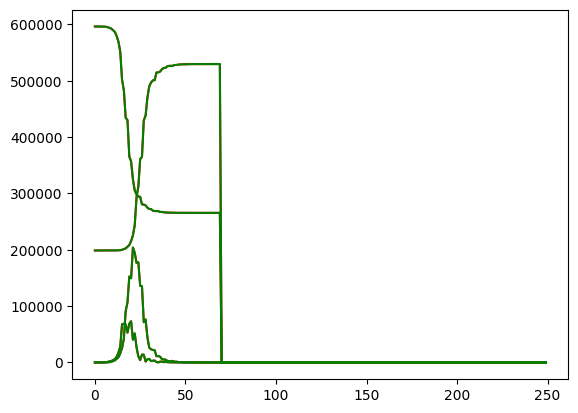

In [172]:
plt.plot(df_ch, color='red')
plt.plot(df_s, color='green')

In [131]:
df_s

,S_H1N1,E_H1N1,I_H1N1,R_H1N1
0,596487.0,5.0,10.0,198834.0
1,596467.0,25.0,10.0,198834.0
2,596459.0,28.0,15.0,198834.0
3,596420.0,47.0,35.0,198834.0
4,596364.0,95.0,43.0,198834.0
...,...,...,...,...
245,0.0,0.0,0.0,0.0
246,0.0,0.0,0.0,0.0
247,0.0,0.0,0.0,0.0
248,0.0,0.0,0.0,0.0


In [120]:
pd.read_csv(folder + 'checking' + pr_file_n.split('seed')[-1])

,S_H1N1,E_H1N1,I_H1N1,R_H1N1
0,636254.0,5.0,10.0,159067.0
1,636234.0,25.0,10.0,159067.0
2,636226.0,28.0,15.0,159067.0
3,636187.0,47.0,35.0,159067.0
4,636131.0,95.0,43.0,159067.0
...,...,...,...,...
245,0.0,0.0,0.0,0.0
246,0.0,0.0,0.0,0.0
247,0.0,0.0,0.0,0.0
248,0.0,0.0,0.0,0.0


In [112]:
df_comps

,S_H1N1,E_H1N1,I_H1N1,R_H1N1
0,636254.0,5.0,10.0,159067.0
1,636234.0,25.0,10.0,159067.0
2,636226.0,28.0,15.0,159067.0
3,636187.0,47.0,35.0,159067.0
4,636131.0,95.0,43.0,159067.0
...,...,...,...,...
245,0.0,0.0,0.0,0.0
246,0.0,0.0,0.0,0.0
247,0.0,0.0,0.0,0.0
248,0.0,0.0,0.0,0.0


In [108]:
d1 = get_comparts(full_pop=795336, I0=10, 
             alpha_v=alpha_v, lambda_v=lambda_v, 
             pr_f = pr_f, inc_f = inc_f)
d1

,S_H1N1,E_H1N1,I_H1N1,R_H1N1
0,636246.0,13.0,10.0,159067.0
1,636239.0,20.0,10.0,159067.0
2,636218.0,28.0,23.0,159067.0
3,636204.0,35.0,30.0,159067.0
4,636181.0,37.0,51.0,159067.0
...,...,...,...,...
245,0.0,0.0,0.0,0.0
246,0.0,0.0,0.0,0.0
247,0.0,0.0,0.0,0.0
248,0.0,0.0,0.0,0.0


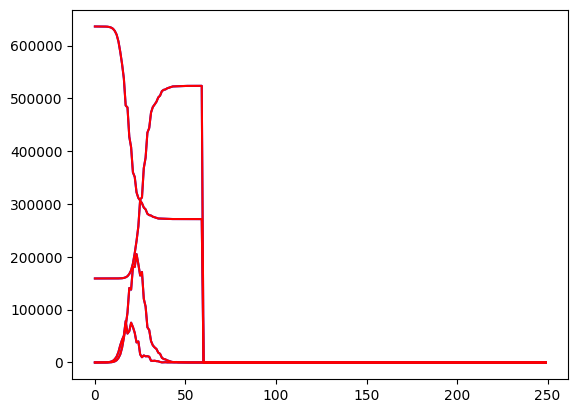

In [110]:
plt.plot(get_comparts(full_pop=795336, I0=10, 
             alpha_v=alpha_v, lambda_v=lambda_v, 
             pr_f = pr_f, inc_f = inc_f),  color='blue')

plt.plot(pd.read_csv(folder+'seirb_seed_9_alpha_0.8_lambda_0.39999999999999997.csv', 
            sep='\t').iloc[:,:4], color='red')

In [93]:
dd = pd.read_csv(folder+'seirb_seed_9_alpha_0.8_lambda_0.39999999999999997.csv', 
            sep='\t')
zero_idx = dd[(dd['E_H1N1']==0)&(dd['I_H1N1']==0)].index[0]

np.int64(60)

In [88]:
dd

,S_H1N1,E_H1N1,I_H1N1,R_H1N1
0,636246.0,13.0,10.0,159067.0
1,636239.0,20.0,10.0,159067.0
2,636218.0,28.0,23.0,159067.0
3,636204.0,35.0,30.0,159067.0
4,636181.0,37.0,51.0,159067.0
...,...,...,...,...
65,0.0,0.0,0.0,0.0
66,0.0,0.0,0.0,0.0
67,0.0,0.0,0.0,0.0
68,0.0,0.0,0.0,0.0


'seirb_seed_9_alpha_0.8_lambda_0.39999999999999997.csv'

In [ ]:
full_pop = 795336
I0 = 10

df_p = pd.read_csv('results/chelyabinsk_0.3_sampled/'+\
                        'prevalence_seed_0.csv', sep='\t')
df_i = pd.read_csv('results/chelyabinsk_0.3_sampled/'+\
                        'incidence_seed_0.csv', sep='\t')

# full_pop * alpha - (E0+I0) = S
S0 = round(full_pop * 0.7) - df_p['H1N1'].values[0]
R0 = full_pop - S0 - df_p['H1N1'].values[0]
E0 = df_p['H1N1'].values[0] - I0
S0, E0, I0, R0, df_p['H1N1'].values[0]

EI = df_p['H1N1'].values
diff_EI = df_i['H1N1'].values
# diff EI -- новые случае ЕИ. тк exposed первые два дня, то суммируем по два дня == exposed
# E
E = pd.Series(diff_EI).rolling(2).sum().values
E[0] = E0

# I
I = EI - E

# S
S = [S0, *(np.array([S0]*9) - diff_EI[1:].cumsum())]



In [20]:
path_to_file.split('/')[-1].split('_')

['seirb', 'seed', '0', 'alpha', '0.7', 'lambda', '0.2.csv']

In [11]:
re.findall(path_to_file, r'alpha_\d{1}.\d{1,2}_')

[]

In [4]:
params = 'seed_0_alpha_0.7_lambda_0.2'

df = pd.read_csv('chelyabinsk_0.3_sampled/'+\
                 f'seirb_{params}.csv', sep='\t')
df['I_H1N1'].iloc[:60]

0         10.0
1         10.0
2         15.0
3         19.0
4         31.0
5         45.0
6         63.0
7        126.0
8        216.0
9        359.0
10       592.0
11      1106.0
12      2087.0
13      2168.0
14      2401.0
15      2771.0
16      3850.0
17      6116.0
18      7796.0
19     13138.0
20     24129.0
21     37222.0
22     49875.0
23     76445.0
24     83942.0
25    103041.0
26     94316.0
27    127710.0
28    115579.0
29    102920.0
30     98329.0
31     75695.0
32     80051.0
33     43642.0
34     42521.0
35     25885.0
36     26708.0
37     24765.0
38     18058.0
39      7568.0
40      8099.0
41     10959.0
42      4562.0
43      5124.0
44      4881.0
45      4949.0
46      4129.0
47      1252.0
48      1245.0
49       676.0
50       709.0
51       551.0
52       120.0
53        81.0
54        72.0
55        82.0
56        49.0
57        36.0
58        31.0
59        19.0
Name: I_H1N1, dtype: float64

In [ ]:
full_pop = 795336
I0 = 10

df_p = pd.read_csv('results/chelyabinsk_0.3_sampled/'+\
                        'prevalence_seed_0.csv', sep='\t')
df_i = pd.read_csv('results/chelyabinsk_0.3_sampled/'+\
                        'incidence_seed_0.csv', sep='\t')

# full_pop * alpha - (E0+I0) = S
S0 = round(full_pop * 0.7) - df_p['H1N1'].values[0]
R0 = full_pop - S0 - df_p['H1N1'].values[0]
E0 = df_p['H1N1'].values[0] - I0
S0, E0, I0, R0, df_p['H1N1'].values[0]

EI = df_p['H1N1'].values
diff_EI = df_i['H1N1'].values
# diff EI -- новые случае ЕИ. тк exposed первые два дня, то суммируем по два дня == exposed
# E
E = pd.Series(diff_EI).rolling(2).sum().values
E[0] = E0

# I
I = EI - E

# S
S = [S0, *(np.array([S0]*9) - diff_EI[1:].cumsum())]

<Axes: >

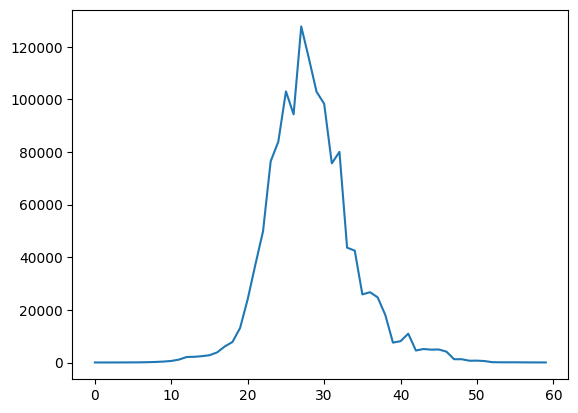

In [8]:
params = 'seed_0_alpha_0.7_lambda_0.2'

df = pd.read_csv('chelyabinsk_0.3_sampled/'+\
                 f'seirb_{params}.csv', sep='\t')
df['I_H1N1'].iloc[:60].plot()

<Axes: >

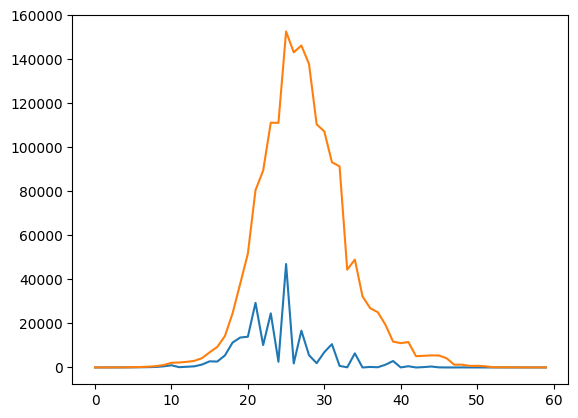

In [13]:
df_i = pd.read_csv('chelyabinsk_0.3_sampled/'+\
                 f'incidence_{params}.csv', sep='\t')
df_p = pd.read_csv('chelyabinsk_0.3_sampled/'+\
                 f'prevalence_{params}.csv', sep='\t')
df_i['H1N1'].iloc[:60].plot()
df_p['H1N1'].iloc[:60].plot()

In [14]:
df_i['H1N1'].iloc[:10]

0      5
1      4
2     12
3     14
4     28
5     63
6     95
7    147
8    245
9    528
Name: H1N1, dtype: int64

In [15]:
df_p['H1N1'].iloc[:10]

0      15
1      19
2      31
3      45
4      73
5     136
6     221
7     368
8     608
9    1132
Name: H1N1, dtype: int64

In [17]:
df.iloc[:10,:4]

,S_H1N1,E_H1N1,I_H1N1,R_H1N1
0,556720.0,5.0,10.0,238601.0
1,556716.0,9.0,10.0,238601.0
2,556704.0,16.0,15.0,238601.0
3,556690.0,26.0,19.0,238601.0
4,556662.0,42.0,31.0,238601.0
5,556599.0,91.0,45.0,238601.0
6,556504.0,158.0,63.0,238611.0
7,556357.0,242.0,126.0,238611.0
8,556112.0,392.0,216.0,238616.0
9,555584.0,773.0,359.0,238620.0
